### Model

### Data Preprocess

In [1]:
import pandas as pd
train_df = pd.read_csv('data/train_annotated.csv')
test_df = pd.read_csv('data/test_annotated.csv')
train_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11191691,38842535,"['Introduction', 'Results and Discussion', 'Co...","['background', 'conclusions', 'conclusions', '..."
1,PMC11182025,38887617,"['Introduction', 'Materials & Methods', 'Resul...","['background', 'methods', 'results', 'conclusi..."
2,PMC10511328,37704722,"['Main', 'Pooled longitudinal analyses', 'Popu...","['background', 'results', 'results', 'results'..."
3,PMC10632145,37914938,"['Main', 'Population imaging and single-cell a...","['background', 'results', 'results', 'results'..."
4,PMC1084334,15884974,"['Introduction', 'Results', 'Discussion', 'Mat...","['background', 'results', 'conclusions', 'meth..."
...,...,...,...,...
635,PMC11187391,38123960,['Ethics statements'],[nan]
636,PMC11187998,38903349,"['Introduction', 'Case presentation', 'Discuss...","['background', 'methods', 'conclusions', 'conc..."
637,PMC11191920,38905421,"['1. Introduction', '2. Patients and methods',...","['background', 'methods', 'results', 'conclusi..."
638,PMC10978839,38548747,"['Introduction', 'Results', 'Discussion', 'Mat...","['background', 'results', 'conclusions', 'meth..."


In [2]:
test_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11184573,38888203,"['INTRODUCTION', 'MATERIALS AND METHODS', 'DIS...","['background', 'methods', 'conclusions', 'conc..."
1,PMC11183239,38886373,"['Introduction', 'Subjects and methods', 'Resu...","['background', 'methods', 'results', 'conclusi..."
2,PMC11187291,38903966,"['Introduction', 'Methods', 'Results', 'Discus...","['background', 'methods', 'results', 'conclusi..."
3,PMC11177991,38883749,"['INTRODUCTION', 'MATERIALS AND METHODS', 'RES...","['background', 'methods', 'results', 'conclusi..."
4,PMC11187304,38903638,"['Introduction', 'Methods', 'Case reports', 'D...","['background', 'methods', 'methods', 'conclusi..."
...,...,...,...,...
155,PMC11181322,38771959,"['Introduction', 'Results and Discussion', 'Co...","['background', 'conclusions', 'conclusions', '..."
156,PMC11186409,38899065,"['Introduction', 'Materials and methods', 'Res...","['background', 'methods', 'results', 'conclusi..."
157,PMC11185683,38895272,"['Introduction', 'Results', 'Discussion', 'Mat...","['background', 'results', 'conclusions', 'meth..."
158,PMC11161898,38854388,"['METHODS', 'RESULTS', 'DISCUSSION', 'Notes']","['methods', 'results', 'conclusions', 'backgro..."


In [3]:
import ast
import numpy as np

# import numpy as np

def eval_with_nan(x):
    if isinstance(x, list):
        return [np.nan if (isinstance(i, float) and np.isnan(i)) else i for i in x]
    try:
        # 這邊直接 eval 而且給定 locals
        val = eval(x, {"nan": np.nan, "NaN": np.nan, "np": np})
        if isinstance(val, list):
            return [np.nan if (isinstance(i, float) and np.isnan(i)) else i for i in val]
        else:
            return val
    except Exception:
        return x  # 如果 eval 還失敗就原樣保留

# 用在你的 dataframe 上
# df_j['sec-norm'] = df_j['sec-norm'].apply(eval_with_nan)




In [4]:

train_df['sec-title'] = train_df['sec-title'].apply(ast.literal_eval)
test_df['sec-title'] = test_df['sec-title'].apply(ast.literal_eval)
train_df['sec-norm'] = train_df['sec-norm'].apply(eval_with_nan)
test_df['sec-norm'] = test_df['sec-norm'].apply(eval_with_nan)

In [5]:
train_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11191691,38842535,"[Introduction, Results and Discussion, Conclus...","[background, conclusions, conclusions, backgro..."
1,PMC11182025,38887617,"[Introduction, Materials & Methods, Results, D...","[background, methods, results, conclusions, co..."
2,PMC10511328,37704722,"[Main, Pooled longitudinal analyses, Populatio...","[background, results, results, results, result..."
3,PMC10632145,37914938,"[Main, Population imaging and single-cell acti...","[background, results, results, results, result..."
4,PMC1084334,15884974,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, ba..."
...,...,...,...,...
635,PMC11187391,38123960,[Ethics statements],[nan]
636,PMC11187998,38903349,"[Introduction, Case presentation, Discussion, ...","[background, methods, conclusions, conclusions]"
637,PMC11191920,38905421,"[1. Introduction, 2. Patients and methods, 3. ...","[background, methods, results, conclusions, ba..."
638,PMC10978839,38548747,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, ba..."


In [6]:
test_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11184573,38888203,"[INTRODUCTION, MATERIALS AND METHODS, DISCUSSI...","[background, methods, conclusions, conclusions..."
1,PMC11183239,38886373,"[Introduction, Subjects and methods, Results, ...","[background, methods, results, conclusions, co..."
2,PMC11187291,38903966,"[Introduction, Methods, Results, Discussion, C...","[background, methods, results, conclusions, co..."
3,PMC11177991,38883749,"[INTRODUCTION, MATERIALS AND METHODS, RESULTS,...","[background, methods, results, conclusions, co..."
4,PMC11187304,38903638,"[Introduction, Methods, Case reports, Discussi...","[background, methods, methods, conclusions, co..."
...,...,...,...,...
155,PMC11181322,38771959,"[Introduction, Results and Discussion, Conclus...","[background, conclusions, conclusions, methods..."
156,PMC11186409,38899065,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, ba..."
157,PMC11185683,38895272,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods]"
158,PMC11161898,38854388,"[METHODS, RESULTS, DISCUSSION, Notes]","[methods, results, conclusions, background]"


In [7]:
from sklearn.model_selection import train_test_split

# 將 train_df 拆成 87.5% 訓練資料 和 12.5% 驗證資料
train_df, val_df = train_test_split(train_df, test_size=1/8, random_state=42, shuffle=True)

train_df

,PMCID,PMID,sec-title,sec-norm
304,PMC11189173,38900748,"[Introduction, Methods, Result, Discussion, Su...","[background, methods, results, conclusions, ba..."
414,PMC11180756,38887229,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, ba..."
577,PMC11073751,38716403,"[Background, Methods, Results, Discussion, Sup...","[background, methods, results, conclusions, ba..."
259,PMC10962890,38131617,"[INTRODUCTION, METHODS, RESULTS, DISCUSSION, C...","[background, methods, results, conclusions, ba..."
594,PMC11152445,38896724,"[INTRODUCTION, OUTCOMES AFTER INTENSIVE CARE U...","[background, nan, nan, nan, nan, nan, conclusi..."
...,...,...,...,...
71,PMC11192717,38906906,"[Introduction, Results, Discussion, Methods, S...","[background, results, conclusions, methods, ba..."
106,PMC11192365,38857285,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, ba..."
270,PMC11186357,38904030,"[Introduction, Materials and Methods, Results,...","[background, methods, results, conclusions, co..."
435,PMC11189877,38900377,"[Background, Case presentation, Discussion, Co...","[background, methods, conclusions, conclusions]"


In [8]:
val_df

,PMCID,PMID,sec-title,sec-norm
570,PMC11186153,38898433,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, co..."
265,PMC11184630,38894760,"[Introduction, Case presentation, Discussion, ...","[background, methods, conclusions, conclusions]"
291,PMC1065320,15743470,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, co..."
597,PMC11180906,38887537,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, co..."
174,PMC11184868,38886767,"[Background, Stem-cell derived ECs, Adult prog...","[background, nan, nan, nan, nan, conclusions]"
...,...,...,...,...
527,PMC11190884,38842026,"[Introduction, Nucleic Acid, Biomolecules and ...","[background, results, results, results, conclu..."
86,PMC11188041,36347335,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, ba..."
369,PMC11186168,38890641,"[Introduction, Methods, Results, Discussion, A...","[background, methods, results, conclusions, ba..."
636,PMC11187998,38903349,"[Introduction, Case presentation, Discussion, ...","[background, methods, conclusions, conclusions]"


In [28]:
import numpy as np

count = sum(pd.isna(label) for row in test_df["sec-norm"] for label in row if isinstance(row, list))
print(f"Total np.nan labels: {count}")


Total np.nan labels: 29


### model

In [9]:
from torch.utils.data import DataLoader
from transformers import BertTokenizerFast

from transformers import AutoTokenizer, AutoModel



tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")

MAX_LENGTH = 64  # 你希望的最大序列長度

def collate_fn(batch):
    input_ids, attention_masks, labels, word_lists, word_id_lists, group_ids = zip(*batch)
    return (
        torch.stack(input_ids),
        torch.stack(attention_masks),
        torch.stack(labels),
        list(word_lists),
        list(word_id_lists),  # list of lists，不要 stack
        list(group_ids)
    )



In [10]:
import torch
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

# 載入 BERT Tokenizer
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 建立標籤映射表

from torch.utils.data import Dataset
import torch

CHUNK_SIZE = 64
STRIDE = 32

label2id = {"O": 0, "objective": 1, "background": 2, "methods": 3, "results": 4, "conclusions": 5}
id2label = {v: k for k, v in label2id.items()}


class SectionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=CHUNK_SIZE, stride=STRIDE):
        self.examples = []
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length
        self.stride = stride

        for row_idx, (_, row) in enumerate(df.iterrows()):
            sec_titles = row["sec-title"]
            sec_labels = row["sec-norm"]

            inputs_with_sep = []
            labels_with_sep = []

            for title, label in zip(sec_titles, sec_labels):
                tokens = title.split()

                if tokens:  # ✅ 確保不是空 title
                    inputs_with_sep.extend(tokens)
                    labels_with_sep.extend(["O"] * len(tokens))  # 非 [SEP] 位置標成 "O"
                    inputs_with_sep.append(tokenizer.sep_token)
                    labels_with_sep.append(label)

            # 每段一個 SEP，應該對應一個非 "O" 的 label
            non_O_count = sum(1 for l in labels_with_sep if l != "O")
            assert non_O_count == len(sec_labels), f"Expected {len(sec_labels)} labels, but got {non_O_count}"


            encoded = tokenizer(
                inputs_with_sep,
                is_split_into_words=True,
                padding="max_length",
                truncation=True,
                max_length=self.max_length,
                stride=self.stride,
                return_overflowing_tokens=True,
                return_attention_mask=True,
                return_offsets_mapping=True,
                return_tensors="pt",
                add_special_tokens=False  # 🔥 你完全控制 special tokens
            )

            for i in range(len(encoded["input_ids"])):
                input_ids = encoded["input_ids"][i]
                attention_mask = encoded["attention_mask"][i]
                word_ids = encoded.word_ids(batch_index=i)

                token_labels = []
                for word_idx in word_ids:
                    if word_idx is None:
                        token_labels.append(0)  # special token / padding → "O"
                    else:
                        label_str = labels_with_sep[word_idx]
                        label_id = self.label2id.get(label_str, 0)
                        token_labels.append(label_id)

                tokens_this_window = self.tokenizer.convert_ids_to_tokens(input_ids)
                labels = torch.tensor(token_labels, dtype=torch.long)

                self.examples.append((
                    input_ids,
                    attention_mask,
                    labels,
                    inputs_with_sep,  # <--- 換成完整的詞表，而不是 tokenizer tokens
                    word_ids,         # token → word index 映射
                    row_idx
                ))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]



from sklearn.model_selection import train_test_split

train_dataset = SectionDataset(train_df, tokenizer)
val_dataset = SectionDataset(val_df, tokenizer)
test_dataset = SectionDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, collate_fn=collate_fn)



In [11]:
# for example in train_dataset:
example = train_dataset[3]
tokens = train_dataset.tokenizer.convert_ids_to_tokens(
    tokenizer(example[3], is_split_into_words=True, return_tensors='pt', add_special_tokens=False)["input_ids"][0]
)

if tokens[0] == '[CLS]' and tokens[1] == '[CLS]':
    print('replicate')
print(tokens)
print(example[2])
# print(example[4])
# print(example[3])
    # break

['introduction', '[SEP]', 'methods', '[SEP]', 'results', '[SEP]', 'discussion', '[SEP]', 'conflicts', 'of', 'interest', '[SEP]', 'supplementary', 'material', '[SEP]']
tensor([0, 2, 0, 3, 0, 4, 0, 5, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [12]:
len(train_dataset)

604

In [13]:
token_lens = []

for i in range(len(train_dataset)):
    input_ids, attention_mask, labels, _, _, _ = train_dataset[i]
    true_len = attention_mask.sum().item()  # 不包含 padding 的 token 數
    token_lens.append(true_len)

import numpy as np
print(f"🔍 Token length stats (train set):")
print(f"  Max: {max(token_lens)}")
print(f"  Mean: {np.mean(token_lens):.2f}")
print(f"  95th percentile: {np.percentile(token_lens, 95):.2f}")


🔍 Token length stats (train set):
  Max: 64
  Mean: 23.26
  95th percentile: 64.00


In [14]:
# !pip uninstall TorchCRF
# !pip install transformers==4.30.2


In [15]:
import torch.nn as nn
from transformers import BertModel
from torchcrf import CRF

class BERT_CRF(nn.Module):
    def __init__(self, num_labels):
        super(BERT_CRF, self).__init__()
        self.bert = AutoModel.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
        self.hidden_dim = self.bert.config.hidden_size
        self.fc = nn.Linear(self.hidden_dim, num_labels)  # 轉換為標籤 logits
        self.crf = CRF(num_labels, batch_first=True)  # CRF 層

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        emissions = self.fc(sequence_output)  # (batch_size, seq_len, num_labels)

        sequence_output = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        assert input_ids.shape == attention_mask.shape == sequence_output.shape[:2]

        if labels is not None:
            assert input_ids.shape == labels.shape == attention_mask.shape


        if labels is not None:
            loss = -self.crf(emissions, labels, mask=attention_mask.byte(), reduction="mean")
            return loss
        else:
            predictions = self.crf.decode(emissions, mask=attention_mask.byte())
            return predictions


Epoch 1:   0%|          | 0/61 [00:00<?, ?it/s]/jet/home/slin23/.local/lib/python3.12/site-packages/torchcrf/__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:529.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
Epoch 1: 100%|██████████| 61/61 [00:06<00:00,  9.98it/s]


Epoch 1/100 | Train Loss: 667.4973 | Val Loss: 58.3421


Epoch 2: 100%|██████████| 61/61 [00:05<00:00, 10.85it/s]


Epoch 2/100 | Train Loss: 181.7132 | Val Loss: 15.1643


Epoch 3: 100%|██████████| 61/61 [00:05<00:00, 10.85it/s]


...

Epoch 98/100 | Train Loss: 15.6484 | Val Loss: 16.2462


Epoch 99: 100%|██████████| 61/61 [00:06<00:00,  9.75it/s]


Epoch 99/100 | Train Loss: 11.2500 | Val Loss: 22.5368


Epoch 100: 100%|██████████| 61/61 [00:06<00:00,  9.76it/s]


Epoch 100/100 | Train Loss: 7.9016 | Val Loss: 25.2662


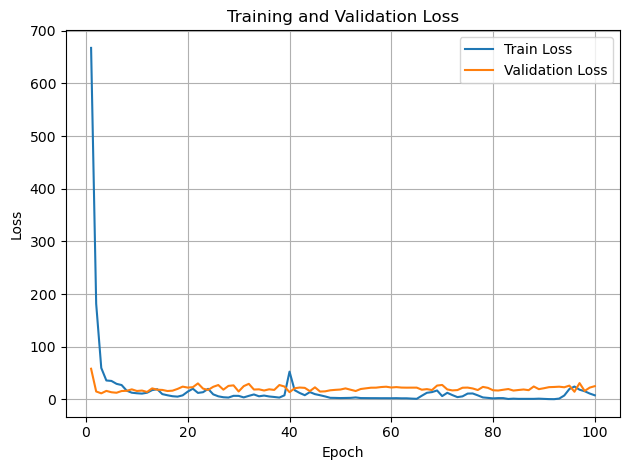

In [16]:
import torch.optim as optim
from tqdm import tqdm

import matplotlib.pyplot as plt

# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERT_CRF(num_labels=len(label2id)).to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-5)

num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]

        optimizer.zero_grad()
        loss = model(input_ids, attention_mask, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # === Validation ===
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
            val_loss = model(input_ids, attention_mask, labels)
            total_val_loss += val_loss.item()

    train_losses.append(total_loss)
    val_losses.append(total_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {total_loss:.4f} | Val Loss: {total_val_loss:.4f}")

plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
torch.save(model.state_dict(), "models/bert_crf_pubMed_pretrained_300seed_64_slide.pth")

In [53]:
from collections import defaultdict
from sklearn.metrics import precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERT_CRF(num_labels=len(label2id)).to(device)
state_dict = torch.load("models/bert_crf_pubMed_pretrained_300seed_64_slide.pth")
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
model.eval()

grouped_preds = defaultdict(dict)
grouped_trues = defaultdict(dict)
seen_keys = set()


# 用來追蹤每個 group_id 已經出現過幾次（第幾個 chunk）
group_chunk_counts = defaultdict(int)

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
        word_lists, word_id_lists, group_ids = batch[3], batch[4], batch[5]

        predictions = model(input_ids, attention_mask)

        for i in range(len(word_lists)):
            group_id = group_ids[i]
            word_list = word_lists[i]
            word_ids = word_id_lists[i]
            preds = predictions[i]
            trues = labels[i]

            # 第幾個 chunk
            chunk_idx = group_chunk_counts[group_id]
            chunk_offset = chunk_idx * (CHUNK_SIZE - STRIDE)
            group_chunk_counts[group_id] += 1

            for j, word_idx in enumerate(word_ids):
                if word_idx is None:
                    continue
                if word_idx >= len(word_list):
                    print(group_id, f"len(word_list): {len(word_list)}, max(word_ids): {max([i for i in word_ids if i is not None])}")
                    continue
                
                word = word_list[word_idx]
                global_word_idx = chunk_offset + word_idx
                
                if word == "[SEP]":
                    word_index = word_ids[j]
                    if word_index is None:
                        continue
                    key = (group_id, word_index)
                    if key in seen_keys:
                        continue
                    seen_keys.add(key)
                    grouped_preds[group_id][global_word_idx] = id2label[preds[j]]
                    grouped_trues[group_id][global_word_idx] = id2label[trues[j].item()]


all_true_labels = []
all_pred_labels = []

for gid in sorted(grouped_trues.keys()):
    for idx in sorted(grouped_trues[gid].keys()):
        all_true_labels.append(grouped_trues[gid][idx])
        all_pred_labels.append(grouped_preds[gid][idx])

print(f"True Labels: {len(all_true_labels)}, Pred Labels: {len(all_pred_labels)}")
print(f"Unique True Labels: {set(all_true_labels)}")
print(f"Unique Pred Labels: {set(all_pred_labels)}")

precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels, all_pred_labels, average="macro"
)
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")



True Labels: 1041, Pred Labels: 1041
Unique True Labels: {'background', 'methods', 'O', 'results', 'conclusions', 'objective'}
Unique Pred Labels: {'background', 'methods', 'O', 'results', 'conclusions'}
Test Precision: 0.7901
Test Recall: 0.6899
Test F1 Score: 0.7053


/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
# group_chunk_counts[2]

In [67]:
# test_dataset[2][2]

In [65]:
# grouped_trues

In [64]:
# grouped_trues[93].values()

In [63]:
# test_df['sec-norm'][93]
# # sum(1 for val in grouped_trues[37].values() if val == 'O')

In [62]:
# for batch in test_loader:
#         input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
#         word_lists, word_id_lists, group_ids = batch[3], batch[4], batch[5]

#         predictions = model(input_ids, attention_mask)

#         for i in range(len(word_lists)):
#             group_id = group_ids[i]
#             word_list = word_lists[i]
#             word_ids = word_id_lists[i]
#             preds = predictions[i]
#             trues = labels[i]
#             if group_id == 93:
#                 print(word_list)
#                 # print(trues)

In [58]:
for j in grouped_trues:
    now = sum(1 for val in grouped_trues[j].values() if val == 'O')
    original_count = sum(pd.isna(label) for label in test_df["sec-norm"][j])
    if now != original_count:
        print(j, now, original_count)

In [59]:
# grouped_trues[93]

{4: 'background',
 18: 'O',
 26: 'O',
 33: 'O',
 42: 'O',
 49: 'O',
 58: 'O',
 98: 'O',
 102: 'background',
 105: 'background'}

In [60]:
from sklearn.metrics import accuracy_score
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels, all_pred_labels, average="weighted"
)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print(f"Test Accuracy: {accuracy_score(all_true_labels, all_pred_labels)}")

Test Precision: 0.9506
Test Recall: 0.9500
Test F1 Score: 0.9442
Test Accuracy: 0.9500480307396734


/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
from sklearn.metrics import classification_report

print(classification_report(all_true_labels, all_pred_labels, digits=4))


              precision    recall  f1-score   support

           O     1.0000    0.2759    0.4324        29
  background     0.9675    0.9774    0.9724       487
 conclusions     0.9956    0.9827    0.9891       231
     methods     0.8788    0.9732    0.9236       149
   objective     0.0000    0.0000    0.0000         2
     results     0.8986    0.9301    0.9141       143

    accuracy                         0.9500      1041
   macro avg     0.7901    0.6899    0.7053      1041
weighted avg     0.9506    0.9500    0.9442      1041



/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [26]:
from sklearn.metrics import accuracy_score
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels, all_pred_labels, average="micro"
)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print(f"Test Accuracy: {accuracy_score(all_true_labels, all_pred_labels)}")

Test Precision: 0.9444
Test Recall: 0.9444
Test F1 Score: 0.9444
Test Accuracy: 0.944392082940622


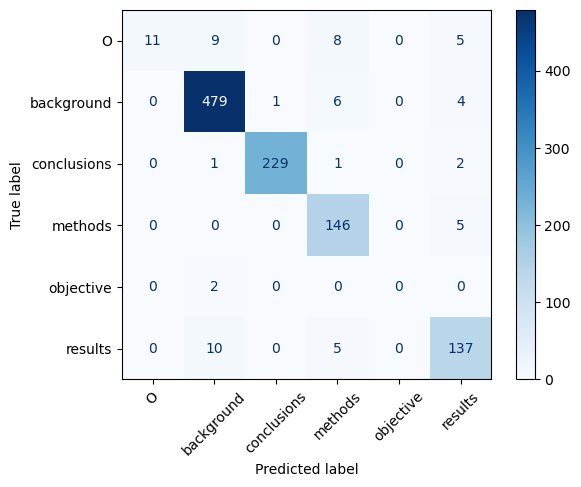

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = sorted(set(all_true_labels) | set(all_pred_labels))  # 統一所有可能的 label

cm = confusion_matrix(all_true_labels, all_pred_labels, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45, cmap="Blues")

### Annotated

In [20]:
import pandas as pd

df = pd.read_csv('Processed_Headings/normalized_section_data 2.csv')
df.head()

,PMCID,PMID,sec-type,sec-title,sec-norm
0,PMC5427117,28337662,NaN,Introduction,background
1,PMC5427117,28337662,NaN,Methods,methods
2,PMC5427117,28337662,NaN,Results,results
3,PMC5427117,28337662,NaN,Discussion,conclusions
4,PMC5427117,28337662,NaN,Electronic supplementary material,background


In [21]:
df_grouped = df.groupby(["PMCID", "PMID"]).agg(list)
df_grouped

,,sec-type,sec-title,sec-norm
PMCID,PMID,,,
PMC10005960,36920161,"[nan, nan, nan, nan, nan, nan, nan, materials|...","[Main, Under-ice features and seafloor bedform...","[nan, nan, nan, nan, nan, nan, methods, nan, b..."
PMC10017507,36922611,"[nan, nan, nan, nan, nan, materials|methods, m...","[Main, Heterogeneous integration of LiNbO, Las...","[nan, nan, nan, nan, nan, methods, nan, backgr..."
PMC10017516,36922610,"[nan, nan, nan, nan, discussion, materials|met...","[Main, Changes in ice thickness distribution, ...","[nan, nan, nan, nan, conclusions, methods, nan..."
PMC10017518,36890228,"[nan, nan, nan, nan, nan, conclusion, material...","[Main, Huc reduces menaquinone analogues in ai...","[nan, nan, nan, nan, nan, conclusions, methods..."
PMC10023157,36862748,"[intro, results, discussion, materials|methods...","[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, na..."
...,...,...,...,...
PMC9981461,36759752,"[nan, results, discussion, nan, nan, nan, nan,...","[Main, Results, Discussion, Methods, Supplemen...","[nan, results, conclusions, methods, backgroun..."
PMC9983191,36869359,"[nan, nan, nan, nan, nan]","[Introduction, Methods, Results, Discussion, S...","[background, methods, results, conclusions, ba..."
PMC9987809,36877706,"[intro, materials|methods, results, conclusion...","[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, nan]"


In [22]:
from sklearn.model_selection import train_test_split
test_df, _ = train_test_split(df_grouped, test_size=0.1, random_state=49, shuffle=True)
len(test_df), len(_)

(1922652, 213629)

In [23]:
test_df = test_df[:100000]

In [24]:
import torch
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict


test_dataset = SectionDataset(test_df, tokenizer)

test_loader = DataLoader(test_dataset, batch_size=10, collate_fn=collate_fn)



In [27]:
from collections import defaultdict
from tqdm import tqdm

grouped_preds = defaultdict(dict)
group_chunk_counts = defaultdict(int)
seen_keys = set()
sec_title = []
sec_norm = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
        word_lists, word_id_lists, group_ids = batch[3], batch[4], batch[5]
        predictions = model(input_ids, attention_mask)

        for i in range(len(word_lists)):
            group_id = group_ids[i]
            word_list = word_lists[i]
            word_ids = word_id_lists[i]
            preds = predictions[i]

            # 計算 chunk offset
            chunk_idx = group_chunk_counts[group_id]
            chunk_offset = chunk_idx * (CHUNK_SIZE - STRIDE)
            group_chunk_counts[group_id] += 1

            for j, word_idx in enumerate(word_ids):
                if word_idx is None or word_idx >= len(word_list):
                    continue

                word = word_list[word_idx]
                global_word_idx = chunk_offset + word_idx
                key = (group_id, global_word_idx)

                if word == "[SEP]" and key not in seen_keys:
                    seen_keys.add(key)
                    grouped_preds[group_id][global_word_idx] = id2label[preds[j]]

# 將 predictions 配對回原始 sec-title（來自 test_df）
for gid in sorted(grouped_preds.keys()):
    pred_dict = grouped_preds[gid]
    sec_idx_sorted = sorted(pred_dict.keys())

    pred_labels = [pred_dict[idx] for idx in sec_idx_sorted]

    # 透過 row_idx (gid) 回查原始 sec-title
    original_titles = test_df.iloc[gid]["sec-title"]

    if len(original_titles) > len(pred_labels):
        original_titles = original_titles[:len(pred_labels)]

    if len(original_titles) != len(pred_labels):
        print(f"⚠️ Mismatch at row {gid}: {len(original_titles)} titles vs {len(pred_labels)} preds")

    sec_title.append(original_titles)
    sec_norm.append(pred_labels)


100%|██████████| 10364/10364 [03:02<00:00, 56.79it/s]


In [35]:
pd.DataFrame({'sec_title': sec_title, 'sec_norm': sec_norm})[593]['sec_title']

,sec_title,sec_norm
590,"[1. Introduction, 2. Antitumor Activity of Bro...","[O, O, O]"
591,"[Introduction, Materials and Methods, Results,...","[background, methods, results, conclusions, co..."
592,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, ba..."
593,"[1. Introduction, 2. Materials and Methods, 3....","[O, O, conclusions, background]"
594,"[Introduction, Methodology, Results, Discussio...","[background, methods, results, conclusions, co..."
595,"[Background, Methods/Design, Discussion, Concl...","[background, conclusions, conclusions, conclus..."
596,"[Background, Methods, Results, Discussion, Con...","[background, methods, results, conclusions, co..."
597,"[Introduction, Materials and Methods, Results,...","[background, methods, results, conclusions]"
598,"[Introduction, Methods, Discussion, Acknowledg...","[background, methods, conclusions, O, conclusi..."
599,"[Background, Methods, Discussion, Conclusion]","[background, methods, conclusions, conclusions]"


In [29]:
pd.DataFrame({'sec_title': sec_title, 'sec_norm': sec_norm}).to_csv('annotated.csv')